In [1]:
###Day 5 woek


# Cell 1 — Load the processed data from Day 4
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

sns.set_style("darkgrid")

# Load processed data (from Day 4)
df = pd.read_csv('../data/creditcard_processed.csv')

print("✅ Processed data loaded!")
print("Shape:", df.shape)
print("\nClass distribution:")
print(df['Class'].value_counts())

✅ Processed data loaded!
Shape: (284807, 33)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [2]:
# Cell 2 — Show WHY imbalance is dangerous
total = len(df)
fraud_count = df['Class'].sum()
legit_count = total - fraud_count

print("=== WHY IMBALANCE IS DANGEROUS ===")
print(f"\nTotal transactions: {total:,}")
print(f"Legit: {legit_count:,} ({legit_count/total*100:.2f}%)")
print(f"Fraud: {fraud_count:,} ({fraud_count/total*100:.2f}%)")

print("\n=== THE DUMMY CLASSIFIER PROBLEM ===")
print("If a model predicts EVERYTHING as Legit:")
print(f"  Accuracy = {legit_count/total*100:.2f}%  ← Looks amazing!")
print(f"  But catches 0 out of {fraud_count} fraud cases!")
print(f"  This is USELESS in real life")

print("\n=== WHAT WE NEED ===")
print("  High RECALL → catch as many frauds as possible")
print("  High PRECISION → don't flag too many legit as fraud")
print("  High AUC-ROC → overall model quality")

=== WHY IMBALANCE IS DANGEROUS ===

Total transactions: 284,807
Legit: 284,315 (99.83%)
Fraud: 492 (0.17%)

=== THE DUMMY CLASSIFIER PROBLEM ===
If a model predicts EVERYTHING as Legit:
  Accuracy = 99.83%  ← Looks amazing!
  But catches 0 out of 492 fraud cases!
  This is USELESS in real life

=== WHAT WE NEED ===
  High RECALL → catch as many frauds as possible
  High PRECISION → don't flag too many legit as fraud
  High AUC-ROC → overall model quality


In [3]:
# Cell 3 — Split X and y
X = df.drop('Class', axis=1)
y = df['Class']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())
print("\nTarget distribution:")
print(Counter(y))

Features (X) shape: (284807, 32)
Target (y) shape: (284807,)

Feature columns:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'hour', 'amount_log', 'amount_scaled', 'hour_scaled']

Target distribution:
Counter({0: 284315, 1: 492})


In [4]:
# Cell 4 — Train test split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # reproducibility
    stratify=y            # maintain fraud ratio in both splits
)

print("=== SPLIT COMPLETE ===")
print(f"\nTraining set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"\nTraining fraud count: {y_train.sum()}")
print(f"Test fraud count: {y_test.sum()}")
print(f"\nTraining fraud %: {y_train.sum()/len(y_train)*100:.2f}%")
print(f"Test fraud %: {y_test.sum()/len(y_test)*100:.2f}%")

=== SPLIT COMPLETE ===

Training set: 227,845 samples
Test set: 56,962 samples

Training fraud count: 394
Test fraud count: 98

Training fraud %: 0.17%
Test fraud %: 0.17%


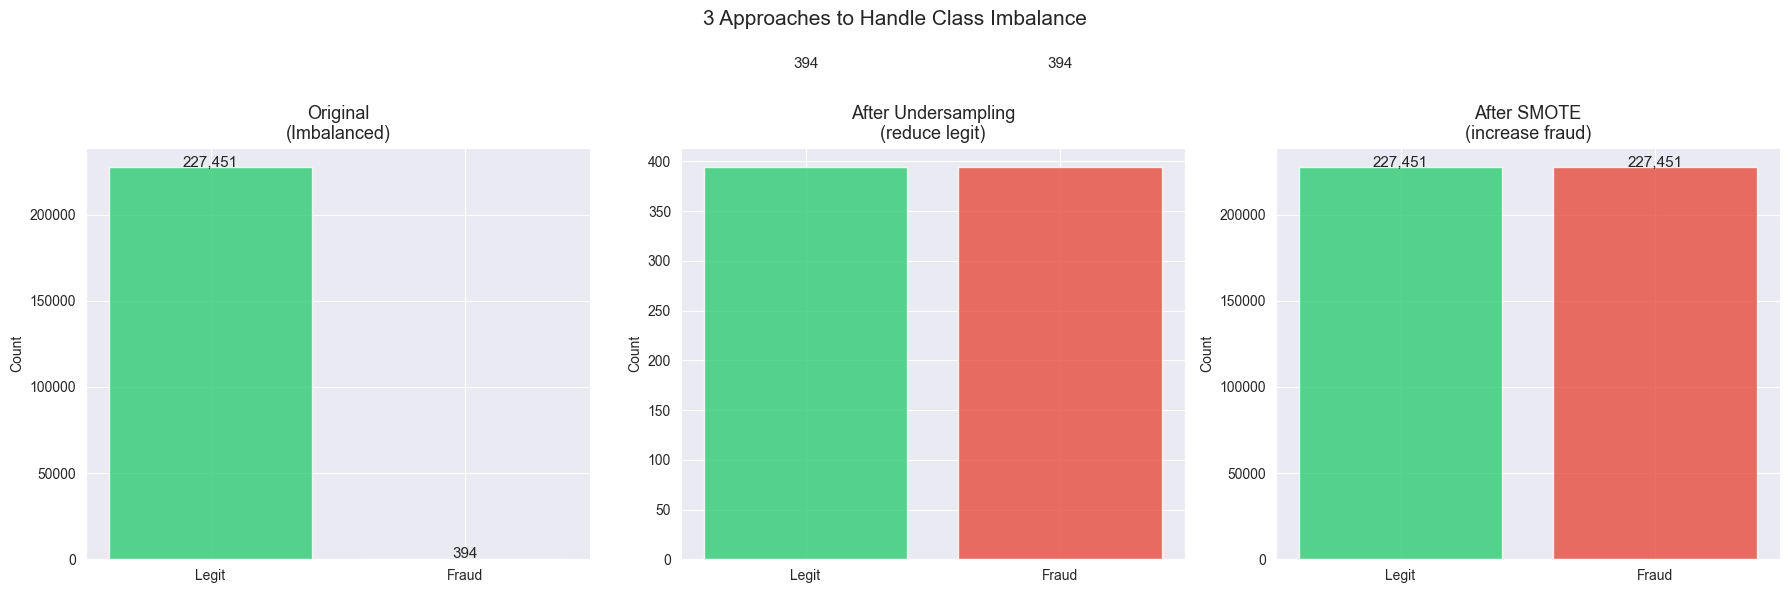

In [5]:
# Cell 5 — Visualize all 3 approaches conceptually
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

approaches = {
    'Original\n(Imbalanced)': [len(y_train) - y_train.sum(), y_train.sum()],
    'After Undersampling\n(reduce legit)': [y_train.sum(), y_train.sum()],
    'After SMOTE\n(increase fraud)': [len(y_train) - y_train.sum(),
                                       len(y_train) - y_train.sum()]
}

colors = [['#2ecc71', '#e74c3c']] * 3

for i, (title, counts) in enumerate(approaches.items()):
    axes[i].bar(['Legit', 'Fraud'], counts,
                color=['#2ecc71', '#e74c3c'], alpha=0.8)
    axes[i].set_title(title, fontsize=13)
    axes[i].set_ylabel('Count')
    for j, count in enumerate(counts):
        axes[i].text(j, count + 100, f'{count:,}',
                    ha='center', fontsize=11)

plt.suptitle('3 Approaches to Handle Class Imbalance',
             fontsize=15)
plt.tight_layout()
plt.savefig('../data/imbalance_approaches.png')
plt.show()

In [6]:
# Cell 6 — Undersampling
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_train, y_train)

print("=== AFTER UNDERSAMPLING ===")
print(f"Training samples: {len(X_under):,}")
print(f"Distribution: {Counter(y_under)}")
print(f"\nLegit: {Counter(y_under)[0]:,}")
print(f"Fraud: {Counter(y_under)[1]:,}")
print("\n⚠️ Problem: We lost 99% of our legit data!")
print("This might make model miss real-world legit patterns")

=== AFTER UNDERSAMPLING ===
Training samples: 788
Distribution: Counter({0: 394, 1: 394})

Legit: 394
Fraud: 394

⚠️ Problem: We lost 99% of our legit data!
This might make model miss real-world legit patterns


In [7]:
# Cell 7 — Apply SMOTE
print("Applying SMOTE... (may take 1-2 minutes)")

sm = SMOTE(
    random_state=42,
    k_neighbors=5      # uses 5 nearest neighbors to create samples
)

X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

print("\n=== AFTER SMOTE ===")
print(f"Training samples: {len(X_train_smote):,}")
print(f"Distribution: {Counter(y_train_smote)}")
print(f"\nLegit: {Counter(y_train_smote)[0]:,}")
print(f"Fraud: {Counter(y_train_smote)[1]:,}")
print("\n✅ Now perfectly balanced!")

Applying SMOTE... (may take 1-2 minutes)

=== AFTER SMOTE ===
Training samples: 454,902
Distribution: Counter({0: 227451, 1: 227451})

Legit: 227,451
Fraud: 227,451

✅ Now perfectly balanced!


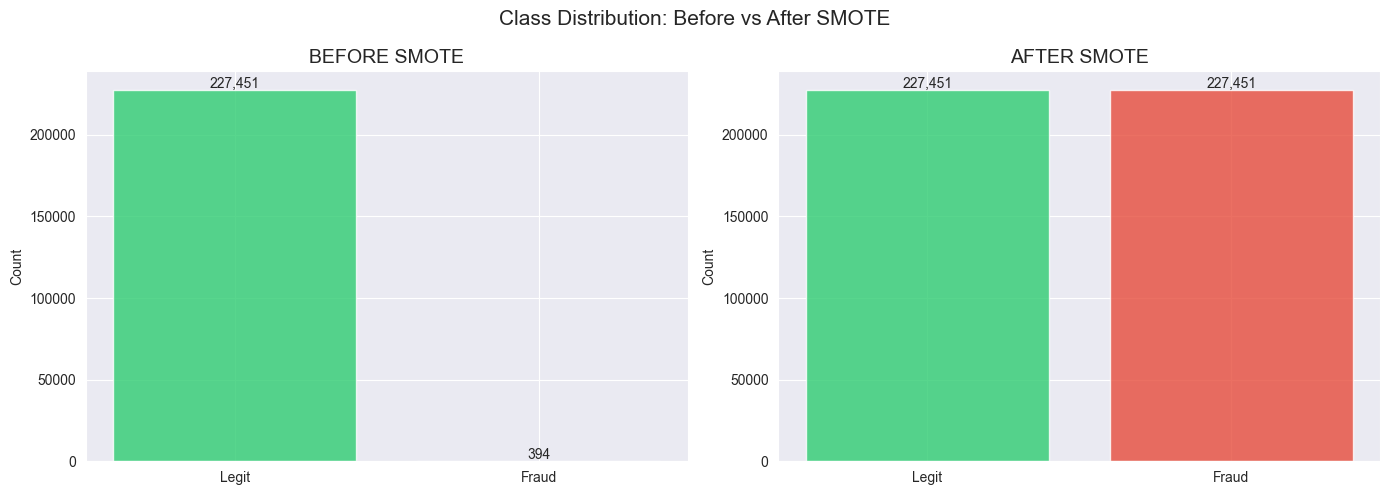

In [8]:
# Cell 8 — Visualize before and after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before SMOTE
before = Counter(y_train)
axes[0].bar(['Legit', 'Fraud'],
            [before[0], before[1]],
            color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[0].set_title('BEFORE SMOTE', fontsize=14)
axes[0].set_ylabel('Count')
axes[0].text(0, before[0] + 1000, f'{before[0]:,}', ha='center')
axes[0].text(1, before[1] + 1000, f'{before[1]:,}', ha='center')

# After SMOTE
after = Counter(y_train_smote)
axes[1].bar(['Legit', 'Fraud'],
            [after[0], after[1]],
            color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[1].set_title('AFTER SMOTE', fontsize=14)
axes[1].set_ylabel('Count')
axes[1].text(0, after[0] + 1000, f'{after[0]:,}', ha='center')
axes[1].text(1, after[1] + 1000, f'{after[1]:,}', ha='center')

plt.suptitle('Class Distribution: Before vs After SMOTE',
             fontsize=15)
plt.tight_layout()
plt.savefig('../data/smote_comparison.png')
plt.show()

In [9]:
# Cell 9 — Compare real vs synthetic fraud samples
real_fraud = X_train[y_train == 1]
all_fraud_after = X_train_smote[y_train_smote == 1]

# Synthetic samples are the new ones added
synthetic_count = len(all_fraud_after) - len(real_fraud)

print(f"Real fraud samples: {len(real_fraud)}")
print(f"Synthetic fraud samples created: {synthetic_count}")
print(f"Total fraud after SMOTE: {len(all_fraud_after)}")

print("\n=== REAL FRAUD STATS (V14) ===")
print(real_fraud['V14'].describe())

print("\n=== ALL FRAUD STATS AFTER SMOTE (V14) ===")
all_fraud_df = pd.DataFrame(
    all_fraud_after, columns=X_train.columns
)
print(all_fraud_df['V14'].describe())

Real fraud samples: 394
Synthetic fraud samples created: 227057
Total fraud after SMOTE: 227451

=== REAL FRAUD STATS (V14) ===
count    394.000000
mean      -6.915098
std        4.289203
min      -19.214325
25%       -9.637519
50%       -6.696927
75%       -4.221933
max        3.442422
Name: V14, dtype: float64

=== ALL FRAUD STATS AFTER SMOTE (V14) ===
count    227451.000000
mean         -6.940331
std           4.178601
min         -19.214325
25%          -9.540673
50%          -6.644205
75%          -4.296169
max           3.442422
Name: V14, dtype: float64


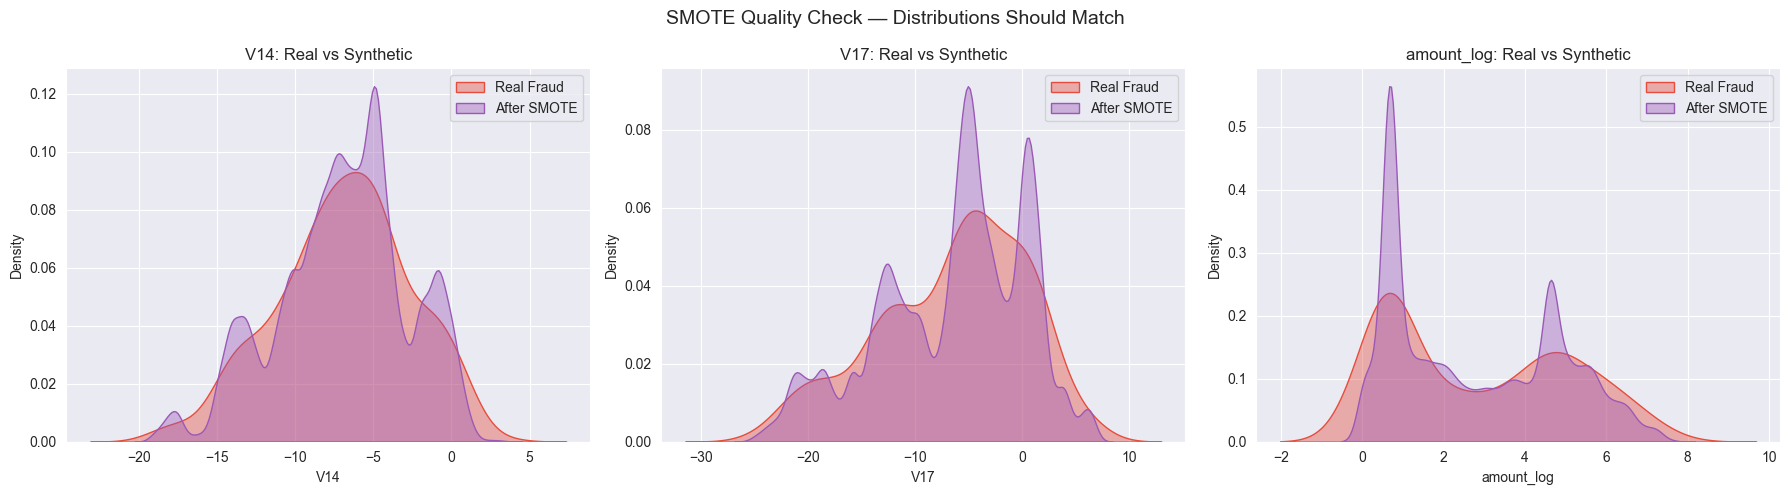

✅ If curves roughly match → SMOTE created realistic samples!


In [10]:
# Cell 10 — KDE comparison: real fraud vs synthetic fraud
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features_to_check = ['V14', 'V17', 'amount_log']

for i, feat in enumerate(features_to_check):
    # Real fraud
    sns.kdeplot(data=real_fraud[feat], ax=axes[i],
                label='Real Fraud', color='#e74c3c',
                fill=True, alpha=0.4)
    # Synthetic fraud
    sns.kdeplot(data=all_fraud_df[feat], ax=axes[i],
                label='After SMOTE', color='#9b59b6',
                fill=True, alpha=0.4)
    axes[i].set_title(f'{feat}: Real vs Synthetic',
                      fontsize=12)
    axes[i].legend()

plt.suptitle('SMOTE Quality Check — Distributions Should Match',
             fontsize=14)
plt.tight_layout()
plt.savefig('../data/smote_quality_check.png')
plt.show()

print("✅ If curves roughly match → SMOTE created realistic samples!")

In [11]:
# Cell 11 — Summary comparison
print("=== COMPARISON OF ALL 3 APPROACHES ===\n")

print(f"{'Approach':<25} {'Total Samples':>15} {'Legit':>10} {'Fraud':>10}")
print("-" * 65)

# Original
orig = Counter(y_train)
print(f"{'Original (imbalanced)':<25} {len(y_train):>15,} "
      f"{orig[0]:>10,} {orig[1]:>10,}")

# Undersampling
under = Counter(y_under)
print(f"{'Undersampling':<25} {len(y_under):>15,} "
      f"{under[0]:>10,} {under[1]:>10,}")

# SMOTE
smote = Counter(y_train_smote)
print(f"{'SMOTE':<25} {len(y_train_smote):>15,} "
      f"{smote[0]:>10,} {smote[1]:>10,}")

print("\n=== WHICH TO USE? ===")
print("✅ SMOTE — keeps all real data + creates realistic fraud samples")
print("⚠️ Undersampling — loses too much legit data")
print("❌ Nothing — model will just predict everything as legit")

=== COMPARISON OF ALL 3 APPROACHES ===

Approach                    Total Samples      Legit      Fraud
-----------------------------------------------------------------
Original (imbalanced)             227,845    227,451        394
Undersampling                         788        394        394
SMOTE                             454,902    227,451    227,451

=== WHICH TO USE? ===
✅ SMOTE — keeps all real data + creates realistic fraud samples
⚠️ Undersampling — loses too much legit data
❌ Nothing — model will just predict everything as legit


In [12]:
# Cell 12 — Save all splits
import pickle
import os

os.makedirs('../data/splits', exist_ok=True)

# Save train/test splits (original)
X_train.to_csv('../data/splits/X_train.csv', index=False)
X_test.to_csv('../data/splits/X_test.csv', index=False)
y_train.to_csv('../data/splits/y_train.csv', index=False)
y_test.to_csv('../data/splits/y_test.csv', index=False)

# Save SMOTE resampled training data
X_train_smote_df = pd.DataFrame(
    X_train_smote, columns=X_train.columns
)
y_train_smote_series = pd.Series(
    y_train_smote, name='Class'
)

X_train_smote_df.to_csv(
    '../data/splits/X_train_smote.csv', index=False
)
y_train_smote_series.to_csv(
    '../data/splits/y_train_smote.csv', index=False
)

print("✅ All splits saved!")
print("\nFiles saved:")
print("  data/splits/X_train.csv")
print("  data/splits/X_test.csv")
print("  data/splits/y_train.csv")
print("  data/splits/y_test.csv")
print("  data/splits/X_train_smote.csv")
print("  data/splits/y_train_smote.csv")

✅ All splits saved!

Files saved:
  data/splits/X_train.csv
  data/splits/X_test.csv
  data/splits/y_train.csv
  data/splits/y_test.csv
  data/splits/X_train_smote.csv
  data/splits/y_train_smote.csv
